## 인프라 사각지대(절대적 공급 부족) 분석
### 질문
- 편의시설 총량(EV+ES)이 하위 수준(5개 이하)임에도 불구하고, 교통약자 이용 비중이 높은 '고위험 사각지대' 역사는 어디인가?
### 가설
- 절대적인 시설 수 자체가 부족한 역은 교통약자의 이동이 가장 심하게 제약되는 지점일 것이며, 이 중 무임 이용 비중이 높은 역은 우선 개선 역으로 분류되어야 한다.
### 분석 방법
- 대상 필터링: 전체 역사 중 편의시설 총합(TOTAL)이 5개 이하인 역들만 추출
- 해당 역들의 무임승하차 비중을 기준으로 내림차순 정렬
- 시각화: 산점도(Scatter Plot)
    - X축: 편의시설 총량 (0~5)
    - Y축: 무임승하차 비중
    - Highlight: 시설은 적고, 비중은 높은 영역에 위치한 역들을 시각적으로 강조

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [2]:
base_df = pd.read_csv("../../data/processed/team/subway_merged_base.csv")
base_df

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수
0,제기동,1,501317,269661,511782,290055,1013099,559716,55.25,3,2,5,39979.71
1,종각,1,1112527,151760,1083408,140929,2195935,292689,13.33,4,2,6,16260.50
2,종로5가,1,712905,247967,697910,240352,1410815,488319,34.61,3,0,3,40693.25
3,청량리,1,662997,280334,656727,281655,1319724,561989,42.58,2,6,8,40142.07
4,강남,2,2302759,161221,2246564,140970,4549323,302191,6.64,4,0,4,18886.94
...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,충무로,"3,4",867520,119883,893846,121889,1761366,241772,13.73,4,23,27,6199.28
240,충정로,"2,5",417744,63616,436275,64124,854019,127740,14.96,4,8,12,5322.50
241,태릉입구,"6,7",438855,87568,443702,85169,882557,172737,19.57,6,24,30,3598.69
242,합정,"2,6",1379809,113748,1461301,111461,2841110,225209,7.93,7,16,23,5118.39


In [7]:
# 총 시설 수 5이하인 역 필터링
total_under_5_df = base_df[base_df['TOTAL'] <= 5].copy()
total_under_5_df

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수
0,제기동,1,501317,269661,511782,290055,1013099,559716,55.25,3,2,5,39979.71
2,종로5가,1,712905,247967,697910,240352,1410815,488319,34.61,3,0,3,40693.25
4,강남,2,2302759,161221,2246564,140970,4549323,302191,6.64,4,0,4,18886.94
5,강변,2,888712,119587,836482,115283,1725194,234870,13.61,2,2,4,23487.00
9,도림천,2,37399,8718,39669,9693,77068,18411,23.89,2,0,2,2301.38
12,방배,2,485486,78042,499315,77140,984801,155182,15.76,3,2,5,11084.43
18,선릉,2,1557470,234282,1369726,206084,2927196,440366,15.04,3,2,5,31454.71
20,신답,2,47284,9756,52309,10300,99593,20056,20.14,2,0,2,2507.00
27,양천구청,2,197538,53520,206684,54294,404222,107814,26.67,3,2,5,7701.00
29,용답,2,87730,18244,86887,18091,174617,36335,20.81,2,0,2,4541.88


In [8]:
# (TOTAL <= 5)인 역들 무임승하차비중을 기준으로 내림차순 정리
total_under_5_descending_df = total_under_5_df.sort_values(by='무임승하차비중', ascending=False)
total_under_5_descending_df

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수
0,제기동,1,501317,269661,511782,290055,1013099,559716,55.25,3,2,5,39979.71
2,종로5가,1,712905,247967,697910,240352,1410815,488319,34.61,3,0,3,40693.25
95,명일,5,252942,73518,255248,75135,508190,148653,29.25,3,2,5,10618.07
60,홍제,3,530608,146942,503869,144399,1034477,291341,28.16,3,0,3,24278.42
80,개롱,5,190212,53640,196781,55256,386993,108896,28.14,3,2,5,7778.29
50,무악재,3,125533,32954,124422,35259,249955,68213,27.29,3,0,3,5684.42
27,양천구청,2,197538,53520,206684,54294,404222,107814,26.67,3,2,5,7701.00
81,개화산,5,172565,43852,164917,42730,337482,86582,25.66,2,0,2,10822.75
65,미아사거리,4,779304,190582,765423,190213,1544727,380795,24.65,2,2,4,38079.50
59,학여울,3,73982,18231,75530,17950,149512,36181,24.20,3,2,5,2584.36


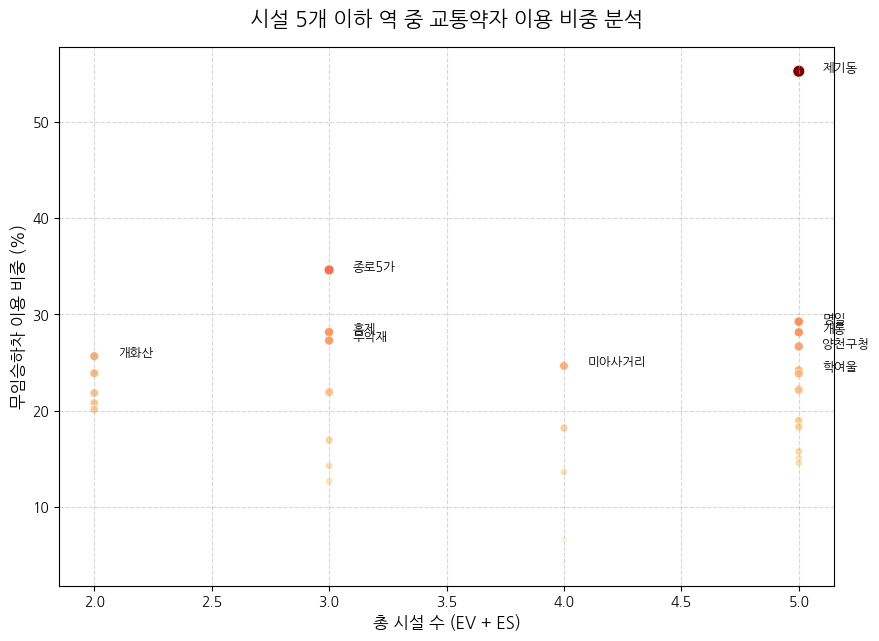

In [10]:
plt.figure(figsize=(10, 7))

# 산점도 그리기 (비중이 높을수록 진하게 표시)
sns.scatterplot(
    data=total_under_5_descending_df,
    x='TOTAL',
    y='무임승하차비중',
    size='무임승하차비중',  # 비중에 따라 점 크기 조절
    hue='무임승하차비중',  # 비중에 따라 색상 조절
    palette='OrRd',
    legend=False
)

# 텍스트 라벨 추가 (상위 몇 개 역만 이름 표시해서 가독성 확보)
# 비중이 높은 상위 10개 역만 이름을 표시합니다.
top_labeled = total_under_5_descending_df.head(10)
for i, row in top_labeled.iterrows():
    plt.text(row['TOTAL']+0.1, row['무임승하차비중'], row['지하철역'], fontsize=9)

plt.title('시설 5개 이하 역 중 교통약자 이용 비중 분석', fontsize=15, pad=15)
plt.xlabel('총 시설 수 (EV + ES)', fontsize=12)
plt.ylabel('무임승하차 이용 비중 (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [14]:
# 시설 1개당 감당해야 하는 체감 비중 계산, 시설이 적을수록 이 수치가 커지므로 사각지대를 찾는 데 유리함
total_under_5_descending_df['시설당_체감비중'] = (
    total_under_5_descending_df['무임승하차비중'] / total_under_5_descending_df['TOTAL']
)

# 절대적인 비중이 높은 역 (예: 제기동)
high_ratio_stations = total_under_5_descending_df.sort_values(by='무임승하차비중', ascending=False).head(3)

# 시설 대비 비중이 너무 높은 사각지대 역
dead_zone_stations = total_under_5_descending_df.sort_values(by='시설당_체감비중', ascending=False).head(3)

# 결과 출력
print("--- [분석 결과 도출] ---")
print(f"1. 이용 비중 최상위(부하 집중): {', '.join(high_ratio_stations['지하철역'].values)}")
print(f"2. 시설 대비 수요 최상위(사각지대): {', '.join(dead_zone_stations['지하철역'].values)}")
print("-" * 30)

# 간단한 요약 코멘트 출력
for _, row in dead_zone_stations.iterrows():
    print(f"'{row['지하철역']}'의 시설은 단 {row['TOTAL']}개뿐인데, 이용 비중은 {row['무임승하차비중']:.1f}%에 달해 집중 관리가 시급함")

--- [분석 결과 도출] ---
1. 이용 비중 최상위(부하 집중): 제기동, 종로5가, 명일
2. 시설 대비 수요 최상위(사각지대): 개화산, 도림천, 종로5가
------------------------------
'개화산'의 시설은 단 2개뿐인데, 이용 비중은 25.7%에 달해 집중 관리가 시급함
'도림천'의 시설은 단 2개뿐인데, 이용 비중은 23.9%에 달해 집중 관리가 시급함
'종로5가'의 시설은 단 3개뿐인데, 이용 비중은 34.6%에 달해 집중 관리가 시급함
